# Step 20 — does federation improve the endotypes?

**Data type: RNA_array** (GSE65391). **Reads:** `step18_site_*` (alone), `step19_site_*` (shared gene
list), `step13_model.rds` and `step12_consensus.rds` (federated), `step10_site_*` (data).
**Writes:** `step20_benefit.rds`, `figures/fig20_RNA_array_federation_benefit.png`.

Three levels, as in `endotypes-proteomics` step 19:

| level | what the sites share | built in |
|---|---|---|
| **alone** | nothing | step 18 |
| **+ shared gene list** | 1,000 gene names | step 19 |
| **+ federated model** | gene list, centring, components, and centroids from federated k-means | steps 11–13 |

Four measures:

1. **Stability.** PAC at each site's chosen k. Lower is better.
2. **Agreement between sites.** Models are parameters, so they can travel. We apply site A's, B's and
   C's models to the **same** validation patients and ask whether they put them in the same groups
   (adjusted Rand index, ARI: 1 is identical, 0 is chance). With one federated model, agreement is 1 by
   construction. That is the point of a shared definition, not a measured gain.
3. **Clinical meaning on unseen patients.** On each site's validation patients (first visit each), is
   the endotype associated with stage, nephritis class, interferon score, SLEDAI, C3, C4,
   anti-dsDNA, white cell, neutrophil or lymphocyte count? We count associations with BH
   (Benjamini–Hochberg) q < 0.05 across the ten. With a federated model, the sites can also **pool** their
   validation patients, because the labels mean the same thing everywhere. Pooling is done from
   summaries: contingency counts, and per-endotype n, sum and sum of squares, which give an exact
   one-way analysis of variance (ANOVA).
4. **Oracle — possible only because this is a simulation.** Agreement (ARI) of each level's labels
   with endotypes found centrally on all discovery patients (round 1's recipe).

In [1]:
source("../src/paths.R")
source("../src/endotypes.R")
source("../src/federation.R")
start_log("20")
fed  <- readRDS(art("step13_model.rds"))
fpac <- readRDS(art("step12_consensus.rds"))$pac
models <- list(
  alone     = lapply(setNames(SITES, SITES), function(s) readRDS(site_file("18", s))),
  shared    = lapply(setNames(SITES, SITES), function(s) readRDS(site_file("19", s))),
  federated = setNames(rep(list(fed), 3), SITES))
LEVELS <- names(models)
apply_model <- function(model, E) as.character(nearest_centroid(t(E[model$genes, , drop = FALSE] - model$centre),
                                                                model$centroids)$endotype)
first_visits <- function(m, split) { d <- m[m$split == split, ]; d <- d[order(d$subject, d$visit), ]
                                     rownames(d)[!duplicated(d$subject)] }

## 1. Stability

In [2]:
stab <- data.frame(level = rep(LEVELS, each = 3), site = rep(SITES, 3),
  k   = c(sapply(models$alone, `[[`, "k"), sapply(models$shared, `[[`, "k"), rep(fed$k, 3)),
  pac = c(sapply(models$alone, function(m) m$pac$pac[m$pac$k == m$k]),
          sapply(models$shared, function(m) m$pac$pac[m$pac$k == m$k]),
          unlist(fpac[fpac$k == fed$k, paste0("pac_", SITES)])))
stab$pac <- round(stab$pac, 3)
stab

level,site,k,pac
<chr>,<chr>,<int>,<dbl>
alone,A,6,0.338
alone,B,5,0.245
alone,C,2,0.057
shared,A,6,0.324
shared,B,5,0.186
shared,C,2,0.075
federated,A,2,0.104
federated,B,2,0.251
federated,C,2,0.108


## 2. Agreement between sites, on the same validation patients

In [3]:
agree <- do.call(rbind, lapply(LEVELS, function(L) do.call(rbind, lapply(SITES, function(v) {
  d <- readRDS(site_file("10", v)); j <- first_visits(d$meta, "validation")
  lab <- lapply(models[[L]], apply_model, E = d$E[, j])
  data.frame(level = L, patients_at = v,
             mean_pairwise_ARI = mean(c(ari(lab$A, lab$B), ari(lab$A, lab$C), ari(lab$B, lab$C))))
}))))
agree$mean_pairwise_ARI <- round(agree$mean_pairwise_ARI, 3)
agree

level,patients_at,mean_pairwise_ARI
<chr>,<chr>,<dbl>
alone,A,0.283
alone,B,0.281
alone,C,0.248
shared,A,0.334
shared,B,0.321
shared,C,0.249
federated,A,1.000
federated,B,1.000
federated,C,1.000


## 3. Clinical associations on validation patients

In [4]:
CONT <- c("ifn_score", "sledai", "c3", "c4", "ds_dna", "wbc", "neutrophil_count", "lymphocyte_count")
CAT  <- c("stage", "nephritis_class")
anova_from_sums <- function(n, s, ss) {           # one-way ANOVA from per-group n, sum, sum of squares
  keep <- n > 0; n <- n[keep]; s <- s[keep]; ss <- ss[keep]
  N <- sum(n); g <- length(n); if (g < 2 || N - g < 1) return(NA)
  between <- sum(s^2 / n) - sum(s)^2 / N; within <- sum(ss - s^2 / n)
  pf((between / (g - 1)) / (within / (N - g)), g - 1, N - g, lower.tail = FALSE)
}
site_summaries <- function(m, lab) {              # what a site would send for pooled tests
  lab <- factor(lab)
  list(cont = lapply(setNames(CONT, CONT), function(v) { ok <- !is.na(m[[v]])
         rbind(n = tapply(ok, lab, sum), s = tapply(ifelse(ok, m[[v]], 0), lab, sum),
               ss = tapply(ifelse(ok, m[[v]]^2, 0), lab, sum)) }),
       cat = lapply(setNames(CAT, CAT), function(v) table(factor(as.character(m[[v]])), lab)))
}
p_from <- function(sm) c(sapply(sm$cont, function(x) anova_from_sums(x["n", ], x["s", ], x["ss", ])),
                         sapply(sm$cat, function(t) { t <- t[rowSums(t) > 0, colSums(t) > 0, drop = FALSE]
                           if (min(dim(t)) < 2) NA else fisher.test(t, simulate.p.value = TRUE, B = 1e4)$p.value }))
set.seed(SEED + 20L)
assoc <- list(); pooled_msgs <- list()
for (L in LEVELS) for (s in SITES) {
  d <- readRDS(site_file("10", s)); j <- first_visits(d$meta, "validation")
  lab <- apply_model(models[[L]][[s]], d$E[, j])
  sm  <- site_summaries(d$meta[j, ], lab)
  p   <- p_from(sm)
  assoc[[paste(L, s)]] <- data.frame(level = L, site = s, patients = length(j),
                                     q_below_0.05 = sum(p.adjust(p, "BH") < 0.05, na.rm = TRUE),
                                     p_below_0.05 = sum(p < 0.05, na.rm = TRUE))
  if (L == "federated") pooled_msgs[[s]] <- send(sm, s, "validation summaries by endotype", length(j))
}
assoc <- do.call(rbind, assoc); rownames(assoc) <- NULL
assoc

level,site,patients,q_below_0.05,p_below_0.05
<chr>,<chr>,<int>,<int>,<int>
alone,A,16,0,1
alone,B,16,0,1
alone,C,16,2,2
shared,A,16,1,2
shared,B,16,0,2
shared,C,16,2,2
federated,A,16,1,1
federated,B,16,0,1
federated,C,16,2,2


### Federated only: pool the three sites' validation patients

In [5]:
pool_sm <- list(
  cont = lapply(setNames(CONT, CONT), function(v) Reduce(`+`, lapply(pooled_msgs, function(x) x$cont[[v]]))),
  cat  = lapply(setNames(CAT, CAT), function(v) {
    tabs <- lapply(pooled_msgs, function(x) x$cat[[v]])
    rn <- sort(unique(unlist(lapply(tabs, rownames))))
    Reduce(`+`, lapply(tabs, function(t) { o <- matrix(0, length(rn), ncol(t), dimnames = list(rn, colnames(t)))
                                           o[rownames(t), ] <- t; o }))
  }))
p_pool <- p_from(pool_sm)
pooled_assoc <- data.frame(variable = names(p_pool), p = signif(p_pool, 2), q = signif(p.adjust(p_pool, "BH"), 2))
pooled_assoc
c(pooled_patients = sum(pool_sm$cont$ifn_score["n", ]), q_below_0.05 = sum(pooled_assoc$q < 0.05, na.rm = TRUE))

,variable,p,q
,<chr>,<dbl>,<dbl>
ifn_score,ifn_score,1.2e-01,0.29000
sledai,sledai,8.5e-01,0.86000
c3,c3,1.7e-01,0.35000
c4,c4,6.8e-03,0.02300
ds_dna,ds_dna,4.5e-01,0.64000
wbc,wbc,5.3e-05,0.00026
neutrophil_count,neutrophil_count,5.0e-05,0.00026
lymphocyte_count,lymphocyte_count,7.8e-01,0.86000
stage,stage,8.6e-01,0.86000


pooled_patients    q_below_0.05 
             48               3

## 4. Oracle — agreement with a central analysis

In [6]:
set.seed(SEED + 21L)
genes <- readRDS(art("step04_genes.rds")); expr <- genes$keep[genes$expressed]
pool_E <- do.call(cbind, lapply(SITES, function(s) readRDS(site_file("10", s))$E))
pool_m <- do.call(rbind, lapply(SITES, function(s) readRDS(site_file("10", s))$meta))
core <- first_visits(pool_m, "discovery")
X <- pool_E[expr, core]; top <- names(sort(apply(X, 1, var), decreasing = TRUE))[1:1000]
centre <- rowMeans(X[top, ]); Z <- t(X[top, ] - centre); S <- prcomp(Z)$x[, 1:10]
C  <- lapply(setNames(2:6, 2:6), function(k) consensus_matrix(S, k))
kc <- choose_k(data.frame(k = 2:6, pac = sapply(C, pac)))
labc <- labels_from_consensus(C[[as.character(kc)]], kc)
central <- list(genes = top, centre = centre, k = kc,
                centroids = t(sapply(levels(labc), function(e) colMeans(Z[labc == e, , drop = FALSE]))))
sle <- rownames(pool_m)[pool_m$disease == "SLE"]
central_lab <- setNames(apply_model(central, pool_E[, sle]), sle)
oracle <- do.call(rbind, lapply(LEVELS, function(L) do.call(rbind, lapply(SITES, function(s) {
  j <- intersect(sle, rownames(pool_m)[pool_m$site == s])
  data.frame(level = L, site = s, ARI_vs_central = round(ari(apply_model(models[[L]][[s]], pool_E[, j]), central_lab[j]), 3))
}))))
c(central_k = kc)
oracle
rm(pool_E)

central_k 
        2

level,site,ARI_vs_central
<chr>,<chr>,<dbl>
alone,A,0.283
alone,B,0.297
alone,C,0.830
shared,A,0.307
shared,B,0.301
shared,C,0.830
federated,A,1.000
federated,B,1.000
federated,C,1.000


## The figure

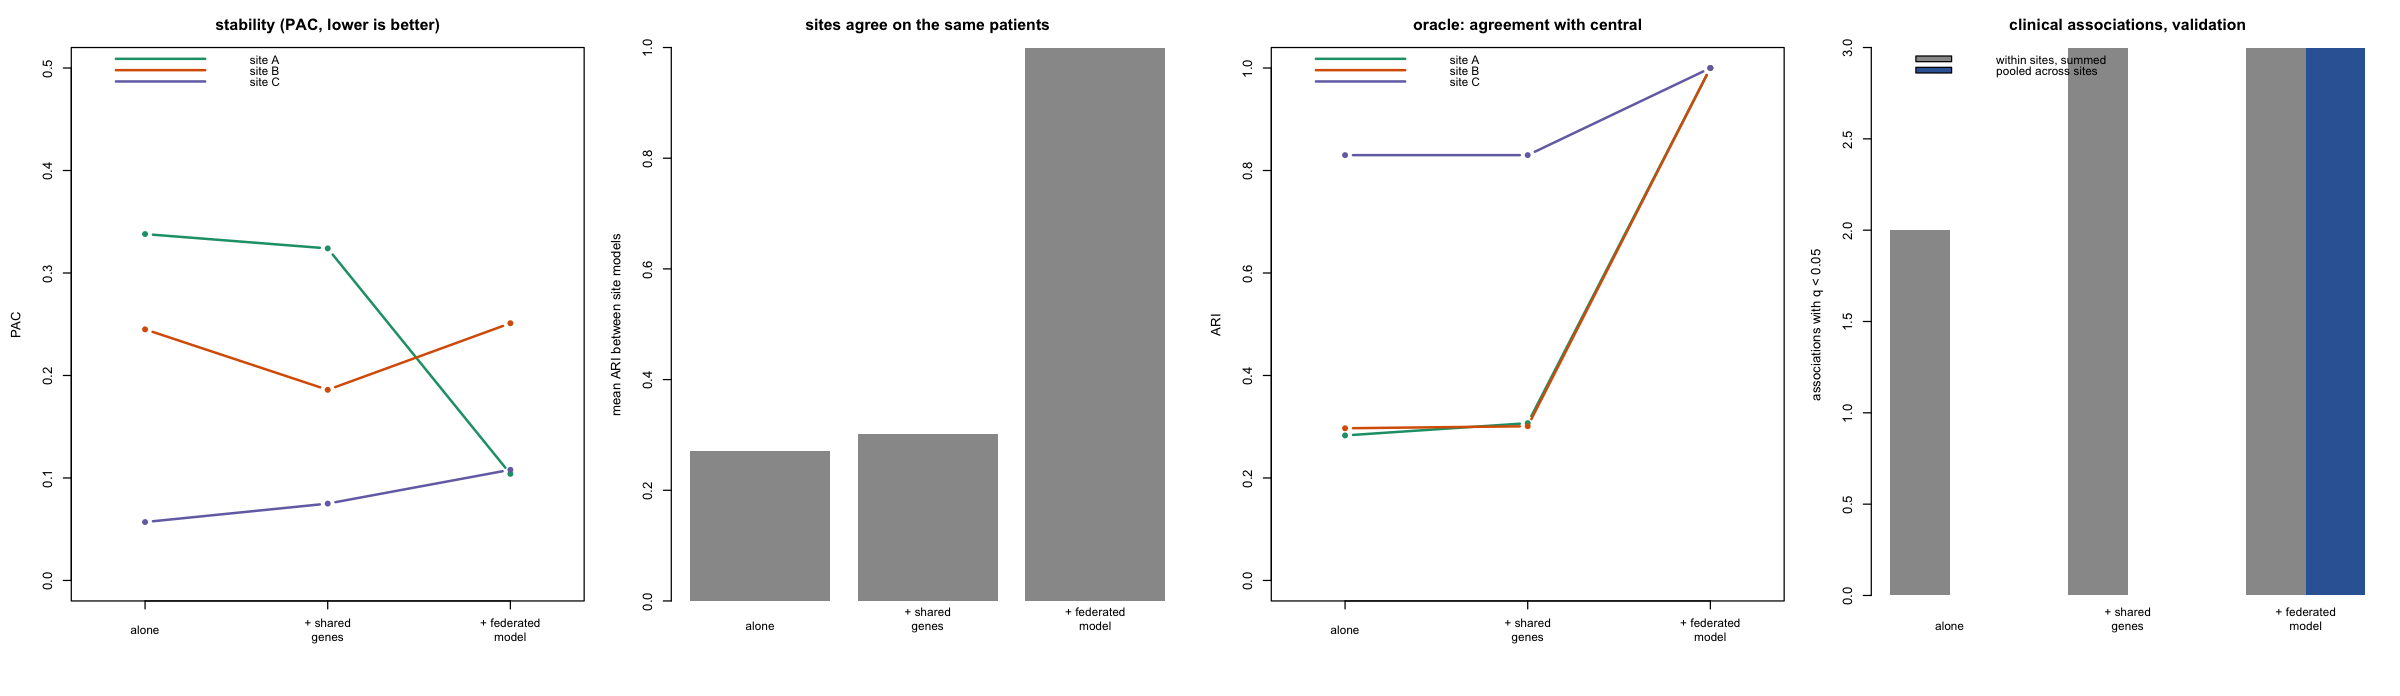

In [7]:
draw_benefit <- function() {
  op <- par(mfrow = c(1, 4), mar = c(6, 4.5, 3, 1))
  cols <- c(A = "#1b9e77", B = "#d95f02", C = "#7570b3"); x <- seq_along(LEVELS)
  lab <- c("alone", "+ shared\ngenes", "+ federated\nmodel")
  slope <- function(df, col, main, ylab, ylim) {
    plot(NULL, xlim = c(0.7, 3.3), ylim = ylim, xaxt = "n", xlab = "", ylab = ylab, main = main)
    axis(1, x, lab, padj = 0.5, cex.axis = 0.9)
    for (s in SITES) { y <- df[df$site == s, col][match(LEVELS, df$level[df$site == s])]
      lines(x, y, col = cols[s], lwd = 2, type = "b", pch = 16) }
    legend("topleft", paste("site", SITES), col = cols, lwd = 2, bty = "n", cex = 0.9)
  }
  slope(stab, "pac", "stability (PAC, lower is better)", "PAC", c(0, 0.5))
  a <- tapply(agree$mean_pairwise_ARI, agree$level, mean)[LEVELS]
  barplot(a, names.arg = lab, ylim = c(0, 1), col = "grey60", border = NA, ylab = "mean ARI between site models",
          main = "sites agree on the same patients", cex.names = 0.9)
  slope(oracle, "ARI_vs_central", "oracle: agreement with central", "ARI", c(0, 1))
  q <- rbind(tapply(assoc$q_below_0.05, assoc$level, sum)[LEVELS],
             c(0, 0, sum(pooled_assoc$q < 0.05, na.rm = TRUE)))
  barplot(q, beside = TRUE, names.arg = lab, col = c("grey60", "#3465A4"), border = NA, ylab = "associations with q < 0.05",
          main = "clinical associations, validation", cex.names = 0.9)
  legend("topleft", c("within sites, summed", "pooled across sites"), fill = c("grey60", "#3465A4"), bty = "n", cex = 0.9)
  par(op)
}
png(fig("fig20_RNA_array_federation_benefit.png"), width = 2800, height = 800, res = 150); draw_benefit(); invisible(dev.off())
options(repr.plot.width = 20, repr.plot.height = 5.8); draw_benefit()

In [8]:
saveRDS(list(stability = stab, agreement = agree, associations = assoc, pooled = pooled_assoc,
             oracle = oracle, central_k = kc), art("step20_benefit.rds"))

## Findings

| | alone | + shared gene list | + federated model |
|---|---|---|---|
| k chosen at sites A, B, C | 6, 5, 2 | 6, 5, 2 | 2, 2, 2 |
| agreement between site models (mean ARI) | 0.27 | 0.30 | 1 (one model) |
| agreement with the central analysis (ARI), A / B / C | 0.28 / 0.30 / 0.83 | 0.31 / 0.30 / 0.83 | 1.00 / 1.00 / 1.00 |
| associations with q < 0.05, within sites (summed) | 2 | 3 | 3 |
| associations with q < 0.05, validation patients pooled | not possible | not possible | 3 |

- **Federation turns three disagreeing answers into one right one.** Alone, only site C recovers the
  structure a central analysis finds. Sites A and B split their 37 patients into five or six groups,
  some of one or two patients, which no other site reproduces. The federated model **is** the
  central answer (ARI 1.00 at every site), without any patient leaving a site.
- **The shared gene list adds almost nothing here**, unlike the proteomics study. The limit is patients
  per site, not the choice of genes.
- **PAC is not comparable across different k.** Site C alone has a lower PAC (0.06) than the federated
  model at site C (0.11), but it is the same k = 2 partition (ARI 0.83 with the central answer). The
  federated model is judged by agreement, not by PAC alone.
- **Only a shared definition lets sites pool their validation patients.** Pooled, the 48 validation
  patients show E2 with higher neutrophil counts (mean 6.4 against 2.9) and white cell counts (8.1
  against 5.0), q = 0.0003 each, and higher C4 (18 against 12, q = 0.02). That fits E2's neutrophil-granule gene signature, and it is tested on patients who
  played no part in finding the endotypes. Within a single site's 16 patients, the same tests rarely
  reach significance.